<h1>Импорт библиотек

In [3]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sum_prod(X, V):
    '''
    X - список матриц (n, n)
    V - список векторов (n, 1)
    Гарантируется, что len(X) == len(V)
    '''
    result = np.zeros((X[0].shape[0], 1))
    for matrix, vector in zip(X, V):
        result += matrix @ vector
    return result

def test_sum_prod():
    X = [np.array([[1, 2], [3, 4]]), np.array([[5, 6], [7, 8]])]
    V = [np.array([[1], [0]]), np.array([[0], [1]])]
    expected = np.array([[1], [3]]) + np.array([[6], [8]])  # [[7], [11]]
    result = sum_prod(X, V)
    assert np.allclose(result, np.array([[7], [11]])), f"Ожидалось [[7], [11]], получено {result}"
    print("Тест 1 пройден")

    X = [np.eye(3)] * 2
    V = [np.array([[1], [2], [3]]), np.array([[4], [5], [6]])]
    result = sum_prod(X, V)
    assert np.allclose(result, np.array([[5], [7], [9]])), f"Ожидалось [[5], [7], [9]], получено {result}"
    print("Тест 2 пройден")

test_sum_prod()

Тест 1 пройден
Тест 2 пройден


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [5]:
def binarize(M, threshold=0.5):
    return (M > threshold).astype(int)

def test_binarize():
    M = np.array([[0.1, 0.6], [0.7, 0.4]])
    expected = np.array([[0, 1], [1, 0]])
    result = binarize(M, 0.5)
    assert np.array_equal(result, expected), f"Ожидалось {expected}, получено {result}"
    print("Тест 1 пройден")

    M = np.array([[1, 2, 3], [4, 5, 6]])
    result = binarize(M, 3)
    expected = np.array([[0, 0, 0], [1, 1, 1]])
    assert np.array_equal(result, expected), f"Ожидалось {expected}, получено {result}"
    print("Тест 2 пройден")

test_binarize()

Тест 1 пройден
Тест 2 пройден


<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [ ]:
def unique_rows(mat):
    return [np.unique(row) for row in mat]

def unique_columns(mat):
    return [np.unique(mat[:, i]) for i in range(mat.shape[1])]

# Тесты для Задачи 3
def test_unique_rows_columns():
    mat = np.array([[1, 2, 2], [3, 3, 4], [1, 2, 5]])
    rows = unique_rows(mat)
    expected_rows = [np.array([1, 2]), np.array([3, 4]), np.array([1, 2, 5])]
    for r, e in zip(rows, expected_rows):
        assert np.array_equal(r, e), f"Ожидалось {e}, получено {r}"
    print("Тест уникальные строки пройден")

    cols = unique_columns(mat)
    expected_cols = [np.array([1, 3]), np.array([2, 3]), np.array([2, 4, 5])]
    for c, e in zip(cols, expected_cols):
        assert np.array_equal(np.sort(c), np.sort(e)), f"Ожидалось {e}, получено {c}"
    print("Тест уникальные столбцы пройден")

test_unique_rows_columns()

Тест unique_rows пройден
Тест unique_columns пройден


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

Мат. ожидания строк: [ 0.42372745  0.66935257 -0.24232586]
Дисперсии строк: [0.70219635 0.41491635 0.45332584]
Мат. ожидания столбцов: [0.07582233 0.33705257 0.39157213 0.32989185]
Дисперсии столбцов: [0.98213778 0.5246849  0.27239382 0.84825692]


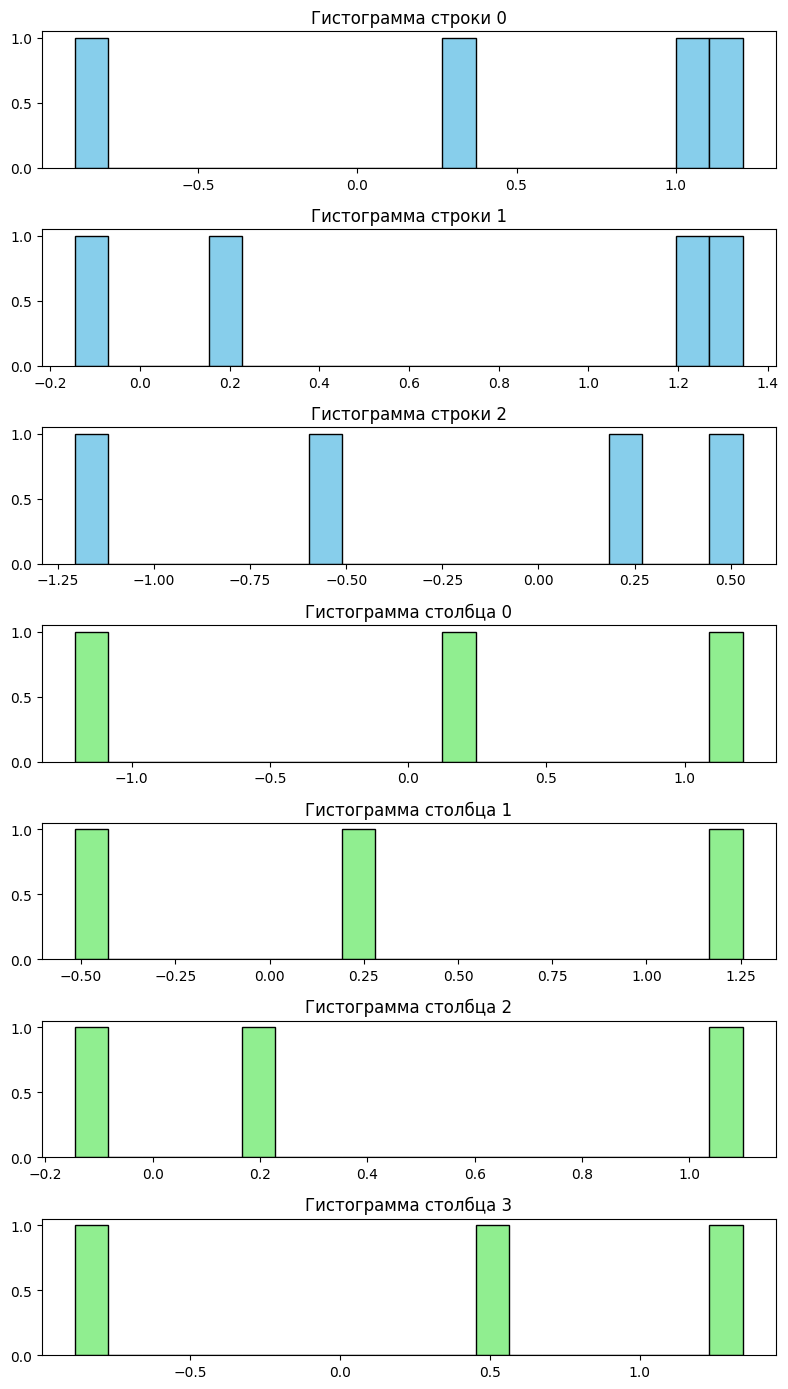

array([[ 1.20914737,  0.27192628,  1.09891632, -0.88508015],
       [ 0.22322384,  1.25496665, -0.14468932,  1.3439091 ],
       [-1.20490422, -0.51573522,  0.22048939,  0.5308466 ]])

In [9]:
def normal_matrix_stats(m, n):
    mat = np.random.randn(m, n)
    
    # Мат. ожидание и дисперсия по строкам и столбцам
    row_means = np.mean(mat, axis=1)
    row_vars = np.var(mat, axis=1)
    col_means = np.mean(mat, axis=0)
    col_vars = np.var(mat, axis=0)
    
    print(f"Мат. ожидания строк: {row_means}")
    print(f"Дисперсии строк: {row_vars}")
    print(f"Мат. ожидания столбцов: {col_means}")
    print(f"Дисперсии столбцов: {col_vars}")
    
    # Гистограммы
    fig, axes = plt.subplots(m + n, 1, figsize=(8, 2*(m+n)))
    for i in range(m):
        axes[i].hist(mat[i, :], bins=20, color='skyblue', edgecolor='black')
        axes[i].set_title(f'Гистограмма строки {i}')
    for j in range(n):
        axes[m + j].hist(mat[:, j], bins=20, color='lightgreen', edgecolor='black')
        axes[m + j].set_title(f'Гистограмма столбца {j}')
    plt.tight_layout()
    plt.show()
    
    return mat
normal_matrix_stats(3, 4)

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [16]:
def chess(m, n, a, b):
    mat = np.zeros((m, n))
    mat[::2, ::2] = a
    mat[1::2, 1::2] = a
    mat[::2, 1::2] = b
    mat[1::2, ::2] = b
    return mat

def test_chess():
    result = chess(3, 4, 1, 0)
    expected = np.array([[1, 0, 1, 0],
                         [0, 1, 0, 1],
                         [1, 0, 1, 0]])
    assert np.array_equal(result, expected), f"Ожидалось:\n{expected}\nПолучено:\n{result}"
    print("Тест 1 пройден")

    result = chess(2, 2, 5, 9)
    expected = np.array([[5, 9], [9, 5]])
    assert np.array_equal(result, expected), f"Ожидалось:\n{expected}\nПолучено:\n{result}"
    print("Тест 2 пройден")

test_chess()

Тест 1 пройден
Тест 2 пройден


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

Тест draw_rectangle пройден
Тест draw_ellipse пройден


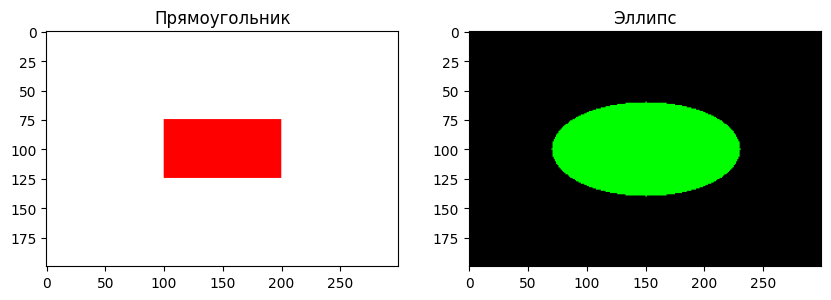

In [17]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    img = np.ones((m, n, 3)) * np.array(background_color)
    x0, y0 = n // 2, m // 2
    x_start = max(0, x0 - a // 2)
    x_end = min(n, x0 + a // 2)
    y_start = max(0, y0 - b // 2)
    y_end = min(m, y0 + b // 2)
    img[y_start:y_end, x_start:x_end] = rectangle_color
    return img

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    img = np.ones((m, n, 3)) * np.array(background_color)
    x0, y0 = n // 2, m // 2
    y, x = np.ogrid[:m, :n]
    mask = ((x - x0) ** 2 / a ** 2) + ((y - y0) ** 2 / b ** 2) <= 1
    img[mask] = ellipse_color
    return img

def test_draw_shapes():
    rect = draw_rectangle(100, 50, 200, 300, [1, 0, 0], [1, 1, 1])
    assert rect.shape == (200, 300, 3)
    assert np.all(rect[75:125, 100:200] == [1, 0, 0])  # центр
    print("Тест draw_rectangle пройден")

    ell = draw_ellipse(80, 40, 200, 300, [0, 1, 0], [0, 0, 0])
    assert ell.shape == (200, 300, 3)
    center_x, center_y = 150, 100
    assert np.allclose(ell[center_y, center_x], [0, 1, 0])
    print("Тест draw_ellipse пройден")

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(rect); plt.title("Прямоугольник")
    plt.subplot(1, 2, 2); plt.imshow(ell); plt.title("Эллипс")
    plt.show()

test_draw_shapes()

<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

Мат. ожидание: 4.20
Дисперсия: 7.76
СКО: 2.79
Локальные максимумы: [(2, np.int64(7)), (4, np.int64(8)), (7, np.int64(9))]
Локальные минимумы: [(3, np.int64(2)), (5, np.int64(1))]
Скользящее среднее (p=3): [3.66666667 4.         5.66666667 3.66666667 4.66666667 5.
 6.         5.        ]


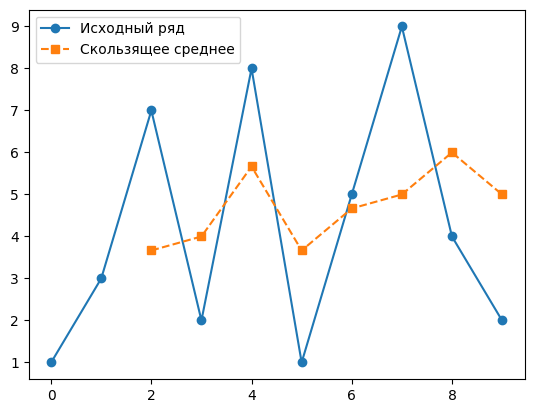

In [19]:
def analyze_time_series(data, p):
    data = np.array(data)
    mean = np.mean(data)
    var = np.var(data)
    std = np.std(data)
    
    local_max = []
    local_min = []
    for i in range(1, len(data) - 1):
        if data[i] > data[i-1] and data[i] > data[i+1]:
            local_max.append((i, data[i]))
        elif data[i] < data[i-1] and data[i] < data[i+1]:
            local_min.append((i, data[i]))
    
    moving_avg = np.convolve(data, np.ones(p), 'valid') / p
    
    return {
        'mean': mean,
        'variance': var,
        'std': std,
        'local_max': local_max,
        'local_min': local_min,
        'moving_average': moving_avg
    }

data = [1, 3, 7, 2, 8, 1, 5, 9, 4, 2]
result = analyze_time_series(data, p=3)

print(f"Мат. ожидание: {result['mean']:.2f}")
print(f"Дисперсия: {result['variance']:.2f}")
print(f"СКО: {result['std']:.2f}")
print(f"Локальные максимумы: {result['local_max']}")
print(f"Локальные минимумы: {result['local_min']}")
print(f"Скользящее среднее (p=3): {result['moving_average']}")

plt.plot(data, 'o-', label='Исходный ряд')
plt.plot(range(2, len(data)), result['moving_average'], 's--', label='Скользящее среднее')
plt.legend()
plt.show()

<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [23]:
def one_hot_encoding(labels):
    labels = np.array(labels)
    num_classes = np.max(labels) + 1
    one_hot = np.zeros((len(labels), num_classes))
    one_hot[np.arange(len(labels)), labels] = 1
    return one_hot

# Тест для Задачи 8
def test_one_hot():
    labels = [0, 2, 3, 0]
    result = one_hot_encoding(labels)
    expected = np.array([[1, 0, 0, 0],
                         [0, 0, 1, 0],
                         [0, 0, 0, 1],
                         [1, 0, 0, 0]])
    assert np.array_equal(result, expected), f"Ожидалось:\n{expected}\nПолучено:\n{result}"
    print("Тест one_hot_encoding пройден")

test_one_hot()

Тест one_hot_encoding пройден
